In [1]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from model_utils import force_model_params, migrate_output_scale_to_input_scale_state_dict
from part2fig_utils import compute_k_params, eval_single_wrap, myplot,  eval_paradigm_with_inoutmaps



# default seed count
seeds = 128//2 # 128*2#*2 # 18#72#18 #128
#

#Big REF1
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesBound/'; seeds = 128*2

#!!!
result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/xlpfSftPlusV2WdepLRscaleOutClmpLRRecvov40m_inj0p4_with_seeds_1'



In [2]:
rcConf = {
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
}
# ufigx,ufigy = (8.5 / 2, 4.2 / 1.5)
ufigx,ufigy = (7.5 / 2, 4.2 / 1.5)

In [3]:
#read saved model parameters
model_state_dict = torch.load(os.path.join(result_path, 'model_state_dict.pt'), map_location='cpu')
# if result_path_aux is not None:
#     model_state_dict_aux = torch.load(os.path.join(result_path_aux, 'model_state_dict.pt'), map_location='cpu')
# plt.hist(model_state_dict['output_scale'].cpu().numpy(), bins=30)
k_params = compute_k_params(model_state_dict)
print(f'detected k_params: {k_params}')

param: log_learning_rate, size: 1
param: log_learning_rate_decay, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
param: x_fast_alpha, size: 1
detected k_params: 6


In [4]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


# seeds = 128*2 # 128*2#*2 # 18#72#18 #128
# seeds = 128 # 128*2#*2 # 18#72#18 #128

subjs = a_exp.shape[1] // seeds

In [5]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])

rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds]) 
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.nanargmin(rmse, axis=1)
# best_rmse = np.nanmin(rmse, axis=1)
best_rmse = rmse[np.arange(subjs), best_seed_idx]
best_rmse_ = rmse_[np.arange(subjs), best_seed_idx]

/tmp/ipykernel_412946/4168741050.py:1: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
/tmp/ipykernel_412946/4168741050.py:3: RuntimeWarning: Mean of empty slice
  rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds])


In [6]:
subjs

16

Text(0, 0.5, 'adaptation')

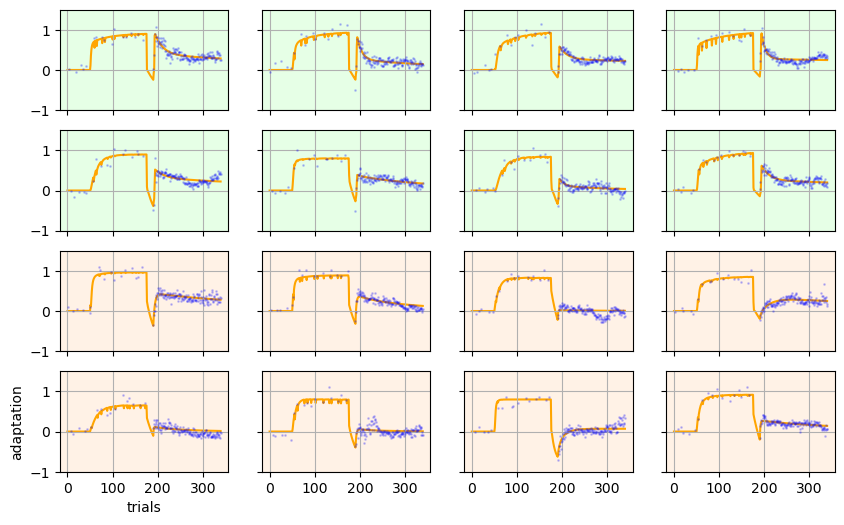

In [7]:
lerner_switch = False


plt.figure(figsize=(10, 6))
plt.subplot(4, 4, 1)
cnt=0
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    this_sub = ii//seeds
    plt.subplot(4, 4, 1 + this_sub)
    polarity = np.sign(np.nanmean(this_exp[:175]))
    if ii % seeds == 0:
        plt.plot(polarity*this_exp,'.', label='Experimental', color='blue', markersize=2, alpha=0.2)
    if ii % seeds == best_seed_idx[this_sub]:
        plt.plot(polarity*this_pred, label='Predicted', color='orange',zorder=0)
        plt.grid() #; print(cnt); cnt+=1
        plt.ylim([-1,1.5])

    if this_sub % 4 > 0:
        plt.gca().set_yticklabels([])
    if this_sub < 12:
        plt.gca().set_xticklabels([])

    if not lerner_switch:
        if this_sub <8:
            # plt.axvspan(0, 340, color='green', alpha=0.01)
            plt.gca().set_facecolor((0.9,1,0.9))
        else:
            # plt.axvspan(0,340, color='orange', alpha=0.1)
            plt.gca().set_facecolor((1,0.95,0.9))
    else:
        if this_sub <15:
            # plt.axvspan(0, 340, color='green', alpha=0.01)
            plt.gca().set_facecolor((0.9,0.9,1))
        else:
            # plt.axvspan(0,340, color='orange', alpha=0.1)
            plt.gca().set_facecolor((0.8,0.7,1))
plt.subplot(4, 4, 13)
plt.xlabel('trials')
plt.ylabel('adaptation')
# plt.title('Experimental vs Predicted Data')
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/ersrFitsM19.pdf', format='pdf', bbox_inches='tight')# 
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/lernerFitsM19.pdf', format='pdf', bbox_inches='tight')

In [8]:
these_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics1000.txt'
coin_bics = np.loadtxt(coin_bics_path)

<StemContainer object of 3 artists>

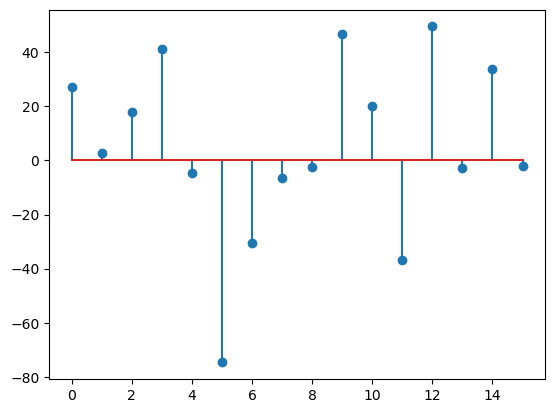

In [9]:
plt.stem(these_bics-coin_bics)

In [10]:
best_seed_idx_within_batch = best_seed_idx +(np.arange(subjs) * seeds)

#create a new model state dict with only the best seeds (seeds are the leading dimension of each parameter tensor)
best_model_state_dict = {}
for key, value in model_state_dict.items():
        print(key, value.shape)
        best_model_state_dict[key] = value[best_seed_idx_within_batch] if not key.startswith('_') else value


log_learning_rate torch.Size([1024, 1])
log_learning_rate_decay torch.Size([1024, 1])
sigma_b torch.Size([1024])
output_scale torch.Size([1024])
sp_weight_decay torch.Size([1024, 1])
sigma_x torch.Size([1024])
x_fast_alpha torch.Size([1024])
_z_biases torch.Size([1024])
_w_in torch.Size([1024])
_w_inq torch.Size([1024])


In [11]:
from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace
args_path = os.path.join(result_path, 'args.yaml')
with open(args_path, 'r') as f:
    args_dict = yaml.unsafe_load(f) #safe_load(f)
args = SimpleNamespace(**args_dict)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [12]:
import pickle

In [13]:
args.bs = subjs  #set batch size to number of subjects

In [14]:
if args.enable_output_scale_tuning:
    if hasattr(args, 'enable_input_scale_tuning') and args.enable_input_scale_tuning:
        raise ValueError('Both output scale tuning and input scale tuning cannot be enabled at the same time, for now.')
    if args.nl_activation != 'relu':
        raise ValueError('Scaling migration is currently only implemented for ReLU nonlinearity'
        '.')
    args.enable_output_scale_tuning = False
    args.enable_input_scale_tuning = True
    # args.softclamp_input_scale_0to1 = args.softclamp_output_scale_0to1 if hasattr(args, 'softclamp_output_scale_0to1') else False

    best_model_state_dict = migrate_output_scale_to_input_scale_state_dict(best_model_state_dict, 
                                                                           remove_output_scale=True,
                                                                           apply_softclamp_output_scale_0to1=args.softclamp_output_scale_0to1 if hasattr(args, 'softclamp_output_scale_0to1') else False,
                                                                           model_for_softclamp=BatchedElboGenerativeModelTopMulti(device=device, args=args) ) 
    print('Migrated output scale parameters to input scale parameters in the model state dict, and disabled output scale tuning while enabling input scale tuning.')
    args.softclamp_output_scale_0to1 = False

# args.fixed_injection_param = 0.4



Migrated output scale parameters to input scale parameters in the model state dict, and disabled output scale tuning while enabling input scale tuning.


In [15]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args, 
                                           **(dict(fudge=args.fudge) if hasattr(args, 'fudge') else {}  )).to(device)
model.get_biases_and_w_in(args.n, device=device)
model.load_state_dict(best_model_state_dict)

<All keys matched successfully>

In [16]:
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3.pkl'

with open(paradigm_file, "rb") as f:
        playlist = pickle.load(f)

In [35]:
my_probe_values = np.arange(-1.5, 1.5 + 0.05 / 2, 0.025, dtype=np.float32)
stopping_point = 150
herz_run_num = 4
recorded_paradigms = [f'herzfeld,z=0.1${herz_run_num}',f'herzfeld,z=0.5${herz_run_num}',f'herzfeld,z=0.9${herz_run_num}']
records = {}
for paradigm in recorded_paradigms:
    records[paradigm] = eval_paradigm_with_inoutmaps(model, args, np.float32(playlist[paradigm][:stopping_point]), my_probe_values)

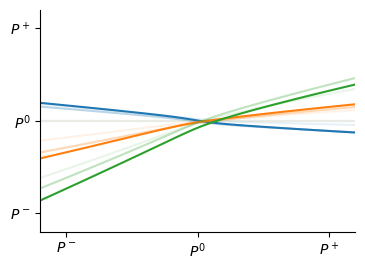

In [40]:
plt.rcParams.update(rcConf)


fig1, ax_map = plt.subplots(figsize=(ufigx, ufigy))
style = '-'

requested_timepoints = [0, 46, 46+45, 46+45*2]
# requested_timepoints += [t+10 for t in requested_timepoints]
colours =  ['tab:blue', 'tab:orange','tab:green']
alphas = [0.05, 0.1, 0.3, 1]
# styles = [,]
for paradigm, colour in zip(recorded_paradigms, colours):
    for t, alpha in zip(requested_timepoints, alphas):
        mean_inout = 1./16*records[paradigm]['inoutmaps'][t].T @ best_model_state_dict['input_scale'].numpy()
        # plt.plot(my_probe_values,records[paradigm]['inoutmaps'][t].mean(axis=0))
        ax_map.plot(my_probe_values,mean_inout, color=colour, linestyle=style, alpha=alpha)
# plt.plot(my_probe_values,my_probe_values, color='black', linestyle=':')

ax_map.set_xticks([-1, 0, 1])
ax_map.set_xticklabels([ '$P^-$', '$P^0$', '$P^+$'])

ax_map.set_yticks([-1, 0, 1])
ax_map.set_yticklabels([ '$P^-$', '$P^0$', '$P^+$'])

# ax_map.set_xlimit([-1, 0, 1])
ax_map.set_ylim([-1.2, 1.2]) 
ax_map.set_xlim([-1.2, 1.2]) 
fig1.tight_layout()
fig1.savefig('part2_herzf_inoutmaps.svg', format='svg', bbox_inches='tight')

NameError: name 'savings' is not defined

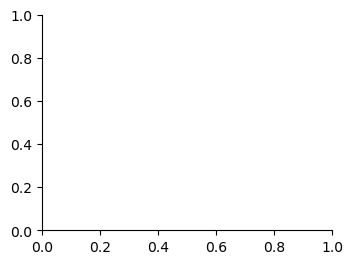

In [20]:



plt.rcParams.update(rcConf)

fig1, ax_traj = plt.subplots(figsize=(ufigx, ufigy))

myplot(savings[:220],align_by_endpoint=False)
myplot(savings[220:],align_by_endpoint=False)

ax_traj.set_xticks(requested_timepoints[:3])
# ax_traj.set_xticklabels([ '$P^+$\n onset', '$P^-$\n onset', '$P^c$\n onset'])
ax_traj.set_xticklabels([ '$P^+$', '$P^-$', '$P^c$'])
ax_traj.set_xlabel('trials')


ax_traj.set_yticks([-1, 0, 1])
ax_traj.set_ylabel('adaptation')

# ax_traj.set_yticklabels([ '$P^+$', '$P^0$', '$P^+$'])